In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

import pyswarms as ps
from deap import base, creator, tools, algorithms
import random

In [2]:
df = pd.read_csv("cleandata.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

series = df['demand_kWh']

series = series.asfreq('h')
series = series.ffill()

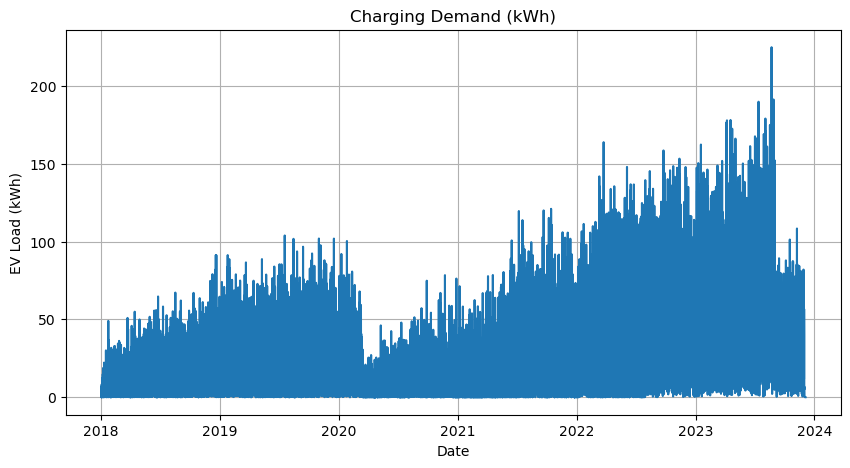

In [22]:
# Plot raw data
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Charging Demand (kWh)")
plt.xlabel("Date")
plt.ylabel("EV Load (kWh)")
plt.grid()
plt.show()

In [4]:
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

In [5]:
#SARIMA
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_fit = sarima_model.fit(method='powell', maxiter=200, disp=False, 
                        low_memory=True, conserve_memory=True)

sarima_pred = sarima_fit.forecast(steps=len(test))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: conserve_memory. After release 0.14, this will raise.
  warnings.warn(


In [6]:
#PREPARE DATA FOR TCN
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 24
X, y = create_sequences(scaled, window)
X_train, X_test = X[:train_size-window], X[train_size-window:]
y_train, y_test = y[:train_size-window], y[train_size-window:]

y_test_inv = scaler.inverse_transform(y_test)

In [7]:
#BUILD TCN
def build_tcn(filters=64, kernel_size=3, dropout=0.2):
    model = Sequential([
        TCN(filters, kernel_size=kernel_size, dropout_rate=dropout, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [8]:
#TCN MODEL
tcn_model = build_tcn()
history_tcn = tcn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

tcn_pred = scaler.inverse_transform(tcn_model.predict(X_test))

Epoch 1/10



2026-05-02 13:02:53,639 - tensorflow - WARNING - From C:\Users\ASUS TUF-Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\core.py:232: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.



1038/1038 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - loss: 0.0370 - val_loss: 0.0050
Epoch 2/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.0022 - val_loss: 0.0038
Epoch 3/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 4/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - loss: 0.0016 - val_loss: 0.0033
Epoch 5/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 6/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 7/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 8/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 9/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.0014 - val_loss: 0.0045
Epoch 10/10
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.0014 - val_loss: 0.0040
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [9]:
#PSO-TCN
def fitness_function(params):
    errors = []
    for p in params:
        model = build_tcn(int(p[0]), int(p[1]), float(p[2]))
        model.fit(X_train, y_train, epochs=5, verbose=0)

        pred = scaler.inverse_transform(model.predict(X_test))
        error = np.mean((pred - y_test_inv)**2)
        errors.append(error)
    return np.array(errors)

bounds = ([32, 2, 0.1], [128, 5, 0.5])

optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1':0.5,'c2':0.3,'w':0.9},
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(fitness_function, iters=5)

pso_model = build_tcn(int(best_pos[0]), int(best_pos[1]), best_pos[2])
history_pso = pso_model.fit(X_train, y_train, epochs=20, validation_split=0.2)

pso_pred = scaler.inverse_transform(pso_model.predict(X_test))

2026-05-02 13:07:48,161 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                 |0/5

325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


pyswarms.single.global_best:  20%|█████████████▏                                                    |1/5, best_cost=175

325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


pyswarms.single.global_best:  40%|██████████████████████████▍                                       |2/5, best_cost=175

...

325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


pyswarms.single.global_best:  80%|████████████████████████████████████████████████████▊             |4/5, best_cost=173

325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step


pyswarms.single.global_best: 100%|██████████████████████████████████████████████████████████████████|5/5, best_cost=172
2026-05-02 14:41:20,056 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 171.8181969419982, best pos: [65.45721181  4.92293614  0.11849766]


Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 57s 43ms/step - loss: 0.0094 - val_loss: 0.0038
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - loss: 0.0015 - val_loss: 0.0049
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - loss: 0.0014 - val_loss: 0.0031
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - loss: 0.0014 - val_loss: 0.0038
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - loss: 0.0014 - val_loss: 0.0042
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - loss: 0.0014 - val_loss: 0.0046
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 11/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - loss: 0.0013 - val_loss: 0.0032
Epoch 12

In [10]:
#GA-TCN
from deap import base, creator, tools, algorithms

if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def eval_individual(ind):
    filters = int(ind[0])
    kernel = int(ind[1])
    dropout = float(ind[2])

    model = build_tcn(filters, kernel, dropout)
    model.fit(X_train, y_train, epochs=5, verbose=0)

    pred = scaler.inverse_transform(model.predict(X_test))
    return (np.mean((pred - y_test_inv)**2),)

toolbox = base.Toolbox()

toolbox.register("attr_filters", random.randint, 32, 128)
toolbox.register("attr_kernel", random.randint, 2, 5)
toolbox.register("attr_dropout", random.uniform, 0.1, 0.5)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_filters, toolbox.attr_kernel, toolbox.attr_dropout), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)

def mutate_individual(ind):
    ind[0] = int(np.clip(ind[0] + random.randint(-10, 10), 32, 128))
    ind[1] = int(np.clip(ind[1] + random.randint(-1, 1), 2, 5))
    ind[2] = float(np.clip(ind[2] + random.uniform(-0.1, 0.1), 0.1, 0.5))
    return (ind,)

toolbox.register("mutate", mutate_individual)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=5)

pop, logbook = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=5,
    verbose=True
)

best_ind = tools.selBest(pop, 1)[0]
print("GA Best:", best_ind)

ga_model = build_tcn(int(best_ind[0]), int(best_ind[1]), float(best_ind[2]))
history_ga = ga_model.fit(X_train, y_train, epochs=20, validation_split=0.2)

ga_pred = scaler.inverse_transform(ga_model.predict(X_test))

325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
gen	nevals
0  	5     
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
1  	1     
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
2  	4     
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
3  	2     
325/325 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step
4  	2     
5  	0     
GA Best: [104, 2, 0.12378853692005057]
Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 86s 68ms/step - loss: 0.0206 - val_loss: 0.0041
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 67s 64ms/step - loss: 0.0019 - val_loss: 0.0039
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - loss: 0.0016 - val_loss: 0.0040
Epoch 4/20
1038/1038 ━━━━

In [11]:
#METRICS
def metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

m_sarima = metrics(test.values, sarima_pred.values)
m_tcn = metrics(y_test_inv.flatten(), tcn_pred.flatten())
m_pso = metrics(y_test_inv.flatten(), pso_pred.flatten())
m_ga = metrics(y_test_inv.flatten(), ga_pred.flatten())

In [12]:
#RESIDUALS
res_sarima = test.values - sarima_pred.values
res_tcn = y_test_inv.flatten() - tcn_pred.flatten()
res_pso = y_test_inv.flatten() - pso_pred.flatten()
res_ga = y_test_inv.flatten() - ga_pred.flatten()

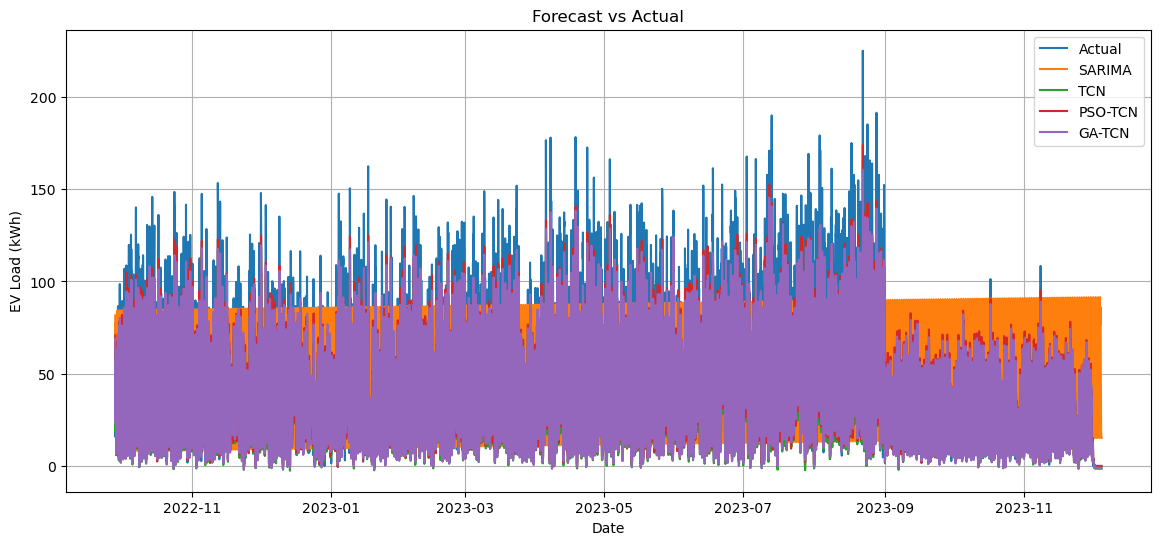

In [23]:
#KEY PLOTS
#Forecast vs Actual
plt.figure(figsize=(14,6))
plt.plot(test.index, test.values, label='Actual')
plt.xlabel("Date")
plt.ylabel("EV Load (kWh)")
plt.plot(test.index, sarima_pred.values, label='SARIMA')
plt.plot(test.index[-len(tcn_pred):], tcn_pred, label='TCN')
plt.plot(test.index[-len(pso_pred):], pso_pred, label='PSO-TCN')
plt.plot(test.index[-len(ga_pred):], ga_pred, label='GA-TCN')
plt.legend(); plt.title("Forecast vs Actual"); plt.grid(); plt.show()

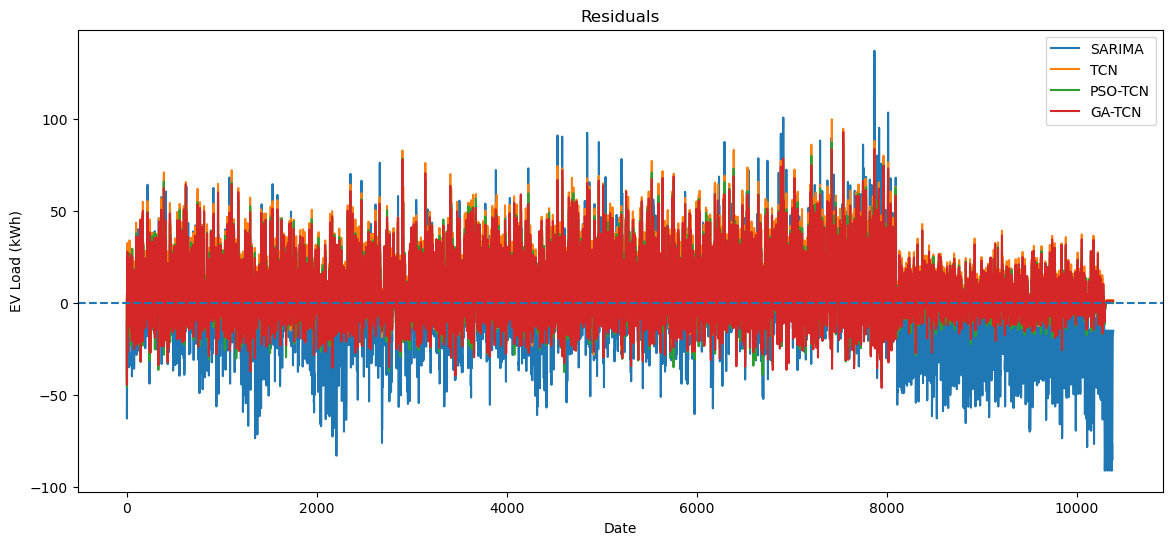

In [24]:
#Residual Plot
plt.figure(figsize=(14,6))
plt.xlabel("Date")
plt.ylabel("EV Load (kWh)")
plt.plot(res_sarima, label='SARIMA')
plt.plot(res_tcn, label='TCN')
plt.plot(res_pso, label='PSO-TCN')
plt.plot(res_ga, label='GA-TCN')
plt.axhline(0, linestyle='--')
plt.legend(); plt.title("Residuals"); plt.show()

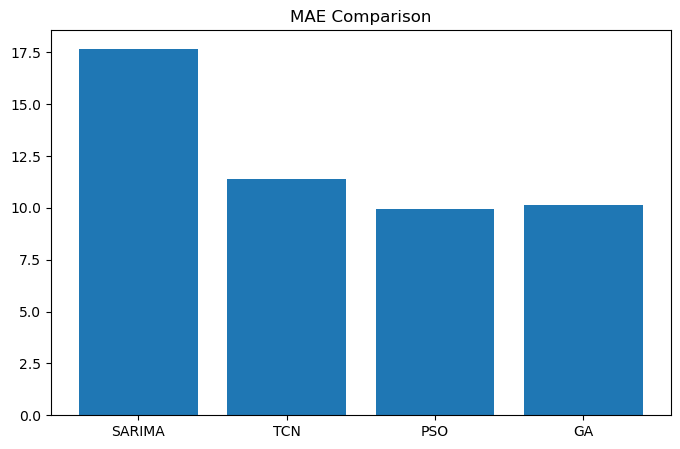

In [15]:
#Error Metrics Bar Chart
labels = ['SARIMA','TCN','PSO','GA']
mae_vals = [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]]

plt.figure(figsize=(8,5))
plt.bar(labels, mae_vals)
plt.title("MAE Comparison")
plt.show()

In [16]:
# UPDATED METRICS: MAE, RMSE, SMAPE, R²
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(actual, pred):
    actual = np.array(actual).flatten()
    pred = np.array(pred).flatten()

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))

    denominator = (np.abs(actual) + np.abs(pred)) / 2
    smape = np.mean(np.where(denominator == 0, 0, np.abs(actual - pred) / denominator)) * 100

    r2 = r2_score(actual, pred)

    return mae, rmse, smape, r2

m_sarima = metrics(test.values, sarima_pred.values)
m_tcn = metrics(y_test_inv.flatten(), tcn_pred.flatten())
m_pso = metrics(y_test_inv.flatten(), pso_pred.flatten())
m_ga = metrics(y_test_inv.flatten(), ga_pred.flatten())

metrics_df = pd.DataFrame({
    "Model": ["SARIMA", "TCN", "PSO-TCN", "GA-TCN"],
    "MAE": [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]],
    "RMSE": [m_sarima[1], m_tcn[1], m_pso[1], m_ga[1]],
    "SMAPE": [m_sarima[2], m_tcn[2], m_pso[2], m_ga[2]],
    "R²": [m_sarima[3], m_tcn[3], m_pso[3], m_ga[3]]
})

metrics_df

,Model,MAE,RMSE,SMAPE,R²
0,SARIMA,17.676194,23.901409,47.379197,0.580002
1,TCN,11.391899,16.954007,33.032532,0.788678
2,PSO-TCN,9.964319,14.976746,26.465608,0.835095
3,GA-TCN,10.157986,15.091795,30.608657,0.832551


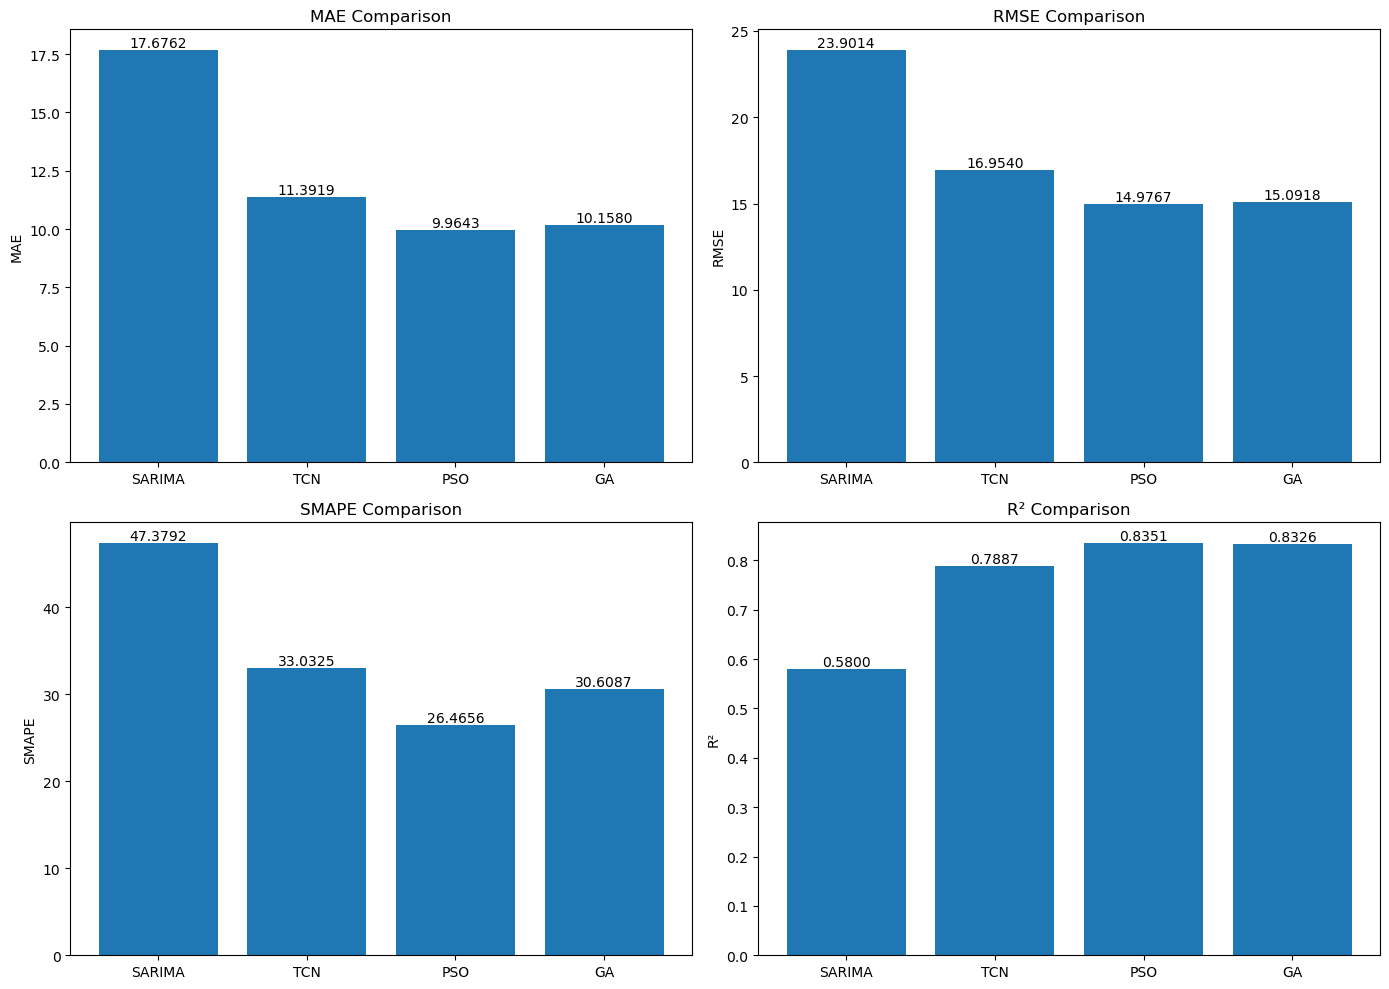

In [17]:
# Error Metrics Bar Charts
labels = ['SARIMA', 'TCN', 'PSO', 'GA']

mae_vals   = [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]]
rmse_vals  = [m_sarima[1], m_tcn[1], m_pso[1], m_ga[1]]
smape_vals = [m_sarima[2], m_tcn[2], m_pso[2], m_ga[2]]
r2_vals    = [m_sarima[3], m_tcn[3], m_pso[3], m_ga[3]]

metrics_data = {
    "MAE Comparison": mae_vals,
    "RMSE Comparison": rmse_vals,
    "SMAPE Comparison": smape_vals,
    "R² Comparison": r2_vals
}

plt.figure(figsize=(14, 10))

for i, (title, values) in enumerate(metrics_data.items(), 1):
    plt.subplot(2, 2, i)
    bars = plt.bar(labels, values)
    plt.title(title)
    plt.ylabel(title.split()[0])

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.4f}",
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

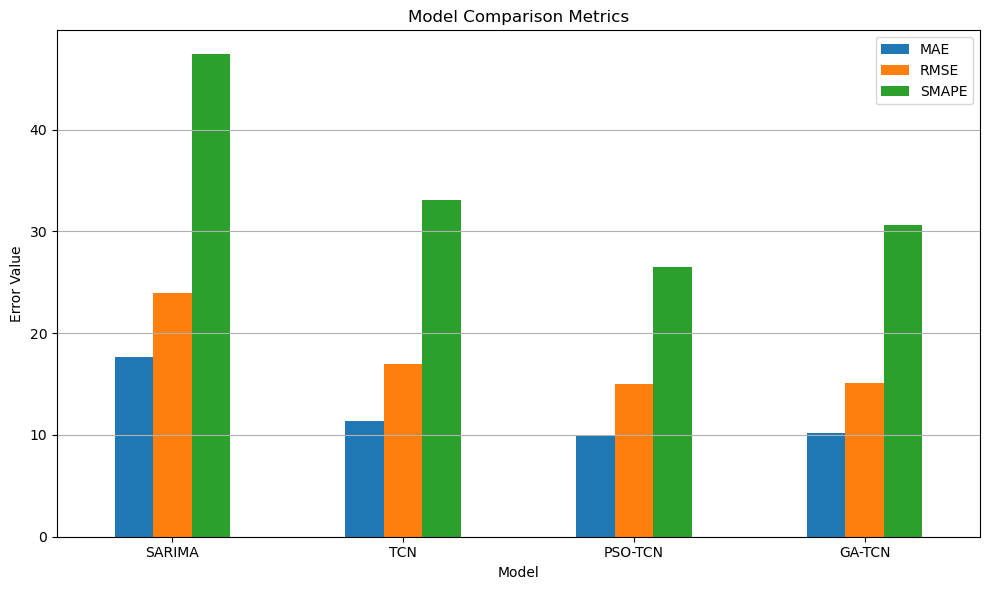

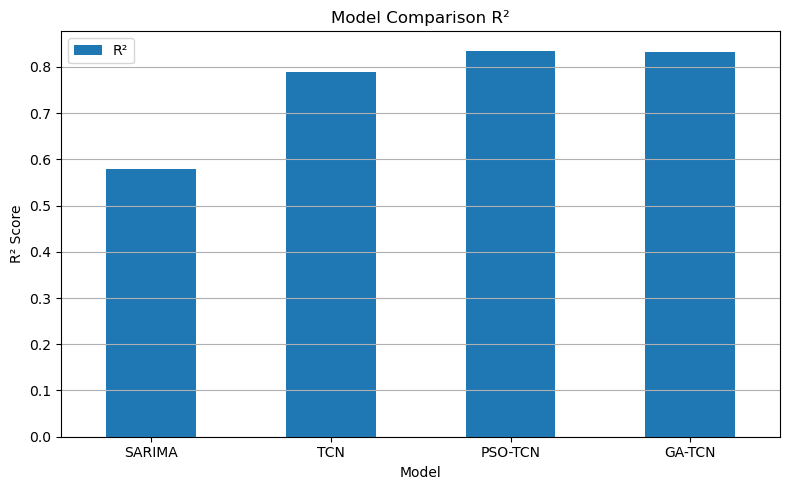

In [19]:
# Metrics comparison for new allModels notebook

plot_df = metrics_df.copy()

# Rename columns if needed
plot_df = plot_df.rename(columns={
    "SMAPE (%)": "SMAPE",
    "R2": "R²",
    "R^2": "R²"
})

# Plot MAE, RMSE, SMAPE
plot_df.set_index("Model")[["MAE", "RMSE", "SMAPE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison Metrics")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Plot R² separately because it uses a different scale
plot_df.set_index("Model")[["R²"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Comparison R²")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

# Extract PSO results
pso_params = {
    "filters": int(round(best_pos[0])),
    "kernel_size": int(round(best_pos[1])),
    "dropout": float(best_pos[2])
}

# Extract GA results
ga_params = {
    "filters": int(round(best_ind[0])),
    "kernel_size": int(round(best_ind[1])),
    "dropout": float(best_ind[2])
}

# Combine into DataFrame
params_df = pd.DataFrame([
    {"Model": "PSO-TCN", **pso_params},
    {"Model": "GA-TCN", **ga_params}
]).set_index("Model")

params_df

,filters,kernel_size,dropout
Model,,,
PSO-TCN,65,5,0.118498
GA-TCN,104,2,0.123789


In [21]:
# ============================================================
# SAVE IMPORTANT DATA / FINAL EXPORTS
# Place this after the metrics and plots cells
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import shutil
import numpy as np
import pandas as pd

try:
    import joblib
except ImportError:
    joblib = None

# ---------- output folders ----------
output_dir = Path("allModels_exports")
output_dir.mkdir(exist_ok=True)

checkpoint_root = Path("notebook_checkpoints")
checkpoint_root.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
checkpoint_dir = checkpoint_root / f"checkpoint_{timestamp}"
checkpoint_dir.mkdir(exist_ok=True)

# ---------- helper ----------
def _flat(x):
    return np.asarray(x).reshape(-1)

# ---------- align data ----------
actual_kwh = _flat(y_test_inv)
sarima_kwh = _flat(sarima_pred.values)
tcn_kwh = _flat(tcn_pred)
pso_tcn_kwh = _flat(pso_pred)
ga_tcn_kwh = _flat(ga_pred)

common_len = min(
    len(actual_kwh),
    len(sarima_kwh),
    len(tcn_kwh),
    len(pso_tcn_kwh),
    len(ga_tcn_kwh)
)

actual_kwh = actual_kwh[-common_len:]
sarima_kwh = sarima_kwh[-common_len:]
tcn_kwh = tcn_kwh[-common_len:]
pso_tcn_kwh = pso_tcn_kwh[-common_len:]
ga_tcn_kwh = ga_tcn_kwh[-common_len:]

timestamps = pd.to_datetime(test.index[-common_len:])

# ---------- forecast / figure-ready data ----------
benchmark_figure_data = pd.DataFrame({
    "timestamp": timestamps,
    "actual_kwh": actual_kwh,
    "sarima_kwh": sarima_kwh,
    "tcn_kwh": tcn_kwh,
    "pso_tcn_kwh": pso_tcn_kwh,
    "ga_tcn_kwh": ga_tcn_kwh
})

# errors
benchmark_figure_data["sarima_error"] = benchmark_figure_data["actual_kwh"] - benchmark_figure_data["sarima_kwh"]
benchmark_figure_data["tcn_error"] = benchmark_figure_data["actual_kwh"] - benchmark_figure_data["tcn_kwh"]
benchmark_figure_data["pso_tcn_error"] = benchmark_figure_data["actual_kwh"] - benchmark_figure_data["pso_tcn_kwh"]
benchmark_figure_data["ga_tcn_error"] = benchmark_figure_data["actual_kwh"] - benchmark_figure_data["ga_tcn_kwh"]

# absolute errors
benchmark_figure_data["sarima_abs_error"] = np.abs(benchmark_figure_data["sarima_error"])
benchmark_figure_data["tcn_abs_error"] = np.abs(benchmark_figure_data["tcn_error"])
benchmark_figure_data["pso_tcn_abs_error"] = np.abs(benchmark_figure_data["pso_tcn_error"])
benchmark_figure_data["ga_tcn_abs_error"] = np.abs(benchmark_figure_data["ga_tcn_error"])

# squared errors
benchmark_figure_data["sarima_sq_error"] = benchmark_figure_data["sarima_error"] ** 2
benchmark_figure_data["tcn_sq_error"] = benchmark_figure_data["tcn_error"] ** 2
benchmark_figure_data["pso_tcn_sq_error"] = benchmark_figure_data["pso_tcn_error"] ** 2
benchmark_figure_data["ga_tcn_sq_error"] = benchmark_figure_data["ga_tcn_error"] ** 2

# ---------- metrics ----------
metrics_df = pd.DataFrame({
    "Model": ["SARIMA", "TCN", "PSO-TCN", "GA-TCN"],
    "MAE": [m_sarima[0], m_tcn[0], m_pso[0], m_ga[0]],
    "RMSE": [m_sarima[1], m_tcn[1], m_pso[1], m_ga[1]],
    "SMAPE": [m_sarima[2], m_tcn[2], m_pso[2], m_ga[2]],
    "R²": [m_sarima[3], m_tcn[3], m_pso[3], m_ga[3]]
})

# ---------- optimized hyperparameters ----------
params_df = pd.DataFrame([
    {
        "Model": "PSO-TCN",
        "filters": int(round(best_pos[0])),
        "kernel_size": int(round(best_pos[1])),
        "dropout": float(best_pos[2])
    },
    {
        "Model": "GA-TCN",
        "filters": int(round(best_ind[0])),
        "kernel_size": int(round(best_ind[1])),
        "dropout": float(best_ind[2])
    }
])

hyperparameters = {
    "pso_tcn": {
        "filters": int(round(best_pos[0])),
        "kernel_size": int(round(best_pos[1])),
        "dropout": float(best_pos[2])
    },
    "ga_tcn": {
        "filters": int(round(best_ind[0])),
        "kernel_size": int(round(best_ind[1])),
        "dropout": float(best_ind[2])
    }
}

# ---------- metadata ----------
metadata_df = pd.DataFrame([
    {"item": "rows_exported", "value": common_len},
    {"item": "start_timestamp", "value": str(timestamps[0])},
    {"item": "end_timestamp", "value": str(timestamps[-1])},
    {"item": "train_size", "value": train_size},
    {"item": "window", "value": window}
])

# ---------- save CSV files ----------
benchmark_figure_data.to_csv(output_dir / "benchmark_figure_data.csv", index=False)
metrics_df.to_csv(output_dir / "benchmark_metrics.csv", index=False)
params_df.to_csv(output_dir / "benchmark_hyperparameters.csv", index=False)
metadata_df.to_csv(output_dir / "benchmark_export_metadata.csv", index=False)

# ---------- save Excel workbook ----------
with pd.ExcelWriter(output_dir / "benchmark_outputs.xlsx", engine="openpyxl") as writer:
    benchmark_figure_data.to_excel(writer, sheet_name="figure_data", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    params_df.to_excel(writer, sheet_name="hyperparameters", index=False)
    metadata_df.to_excel(writer, sheet_name="metadata", index=False)

# ---------- save arrays and forecasts ----------
np.savez_compressed(
    checkpoint_dir / "arrays_and_forecasts.npz",
    X=X,
    y=y,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    y_test_inv=y_test_inv,
    scaled=scaled,
    sarima_pred=sarima_kwh,
    tcn_pred=tcn_pred,
    pso_pred=pso_pred,
    ga_pred=ga_pred
)

# ---------- save scaler ----------
if joblib is not None:
    joblib.dump(scaler, checkpoint_dir / "scaler.pkl")

# ---------- save trained models ----------
tcn_model.save(checkpoint_dir / "tcn_model.keras")
pso_model.save(checkpoint_dir / "pso_tcn_model.keras")
ga_model.save(checkpoint_dir / "ga_tcn_model.keras")

# ---------- save hyperparameters JSON ----------
with open(output_dir / "fixed_hyperparameters.json", "w") as f:
    json.dump(hyperparameters, f, indent=4)

with open(checkpoint_dir / "hyperparameters.json", "w") as f:
    json.dump(hyperparameters, f, indent=4)

# ---------- copy exports into checkpoint ----------
shutil.copytree(output_dir, checkpoint_dir / output_dir.name, dirs_exist_ok=True)

# ---------- checkpoint metadata ----------
checkpoint_metadata = {
    "checkpoint_time": timestamp,
    "checkpoint_folder": str(checkpoint_dir),
    "export_folder": str(output_dir),
    "saved_files": [
        "benchmark_figure_data.csv",
        "benchmark_metrics.csv",
        "benchmark_hyperparameters.csv",
        "benchmark_export_metadata.csv",
        "benchmark_outputs.xlsx",
        "arrays_and_forecasts.npz",
        "scaler.pkl",
        "tcn_model.keras",
        "pso_tcn_model.keras",
        "ga_tcn_model.keras",
        "hyperparameters.json"
    ]
}

with open(checkpoint_dir / "checkpoint_metadata.json", "w") as f:
    json.dump(checkpoint_metadata, f, indent=4)

with open(checkpoint_root / "latest_checkpoint.txt", "w") as f:
    f.write(str(checkpoint_dir))

print("Saved exports to:", output_dir.resolve())
print("Saved checkpoint to:", checkpoint_dir.resolve())
print(metrics_df)

Saved exports to: C:\Users\ASUS TUF-Pc\Desktop\Jupyter Notebook\JERWIN\EV_CHARGING_LOAD-main (test)\allModels_exports
Saved checkpoint to: C:\Users\ASUS TUF-Pc\Desktop\Jupyter Notebook\JERWIN\EV_CHARGING_LOAD-main (test)\notebook_checkpoints\checkpoint_2026-05-02_16-44-48
     Model        MAE       RMSE      SMAPE        R²
0   SARIMA  17.676194  23.901409  47.379197  0.580002
1      TCN  11.391899  16.954007  33.032532  0.788678
2  PSO-TCN   9.964319  14.976746  26.465608  0.835095
3   GA-TCN  10.157986  15.091795  30.608657  0.832551
